# 11 — Portfolio: VWB 3x + corrected `pump_dump_combined`

Correlation and portfolio test between two *independent* strategy lines:

- **`volume_weighted_breakout`** champion (current `strategy.py`, 4h breakout on
  BTC/ETH/SOL/AVAX), bar returns scaled to **3x**;
- **`pump_dump_combined`** surviving book from `15_2_kelly_walkforward`: rollover /
  catastrophe-stop trades (30% pump / 20% dump), **walk-forward classifier** entry
  filter (`pred>0`), realistic **capacity + slippage** engine, per-leg sizing
  **pump 8% / dump 3%** (the aggressive growth tilt WF confirms, nb15_2).

**Why this notebook exists (fixes nb10):** the earlier `10_correlation_*` read
`pump_rollover_visible.parquet` / `dump_rollover_visible.parquet`, which **do not
exist on disk** — so its pump/dump leg was not the real corrected book. Here we
rebuild the stream from the canonical full caches (`pump_rollover.parquet` /
`dump_rollover.parquet`) exactly as the reference notebook `15_2` does.

**Honesty rails.** Window is the visible research period `2024-01-01 → 2026-01-01`;
the pump/dump caches extend to 2026-04 but we **clip to 2026-01-01** so no holdout
months leak in. The classifier is genuinely walk-forward (first 40% of trades pass
unfiltered, the rest are gated by a model trained only on the past). Sizing
`pump8/dump3` is a *fixed rule* (nb15_2's recommendation), not selected on this
window's outcome. For a clean daily-return correlation both legs use a **lump-sum
fixed-fraction** curve (no DCA cashflows to distort daily returns).

In [1]:
import sys, heapq
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from IPython.display import display

sys.path.insert(0, ".")            # cwd = notebooks/volume_weighted_breakout
from _lab import strategy, run_pair, drawdown, monthly_returns, show

REPO = Path("_lab.py").resolve().parents[2]
PD_OUT = REPO / "notebooks" / "pump_dump_combined" / "_out"
PUMP_PARQUET = PD_OUT / "pump_rollover.parquet"
DUMP_PARQUET = PD_OUT / "dump_rollover.parquet"

PERIOD_START, PERIOD_END = "2024-01-01", "2026-01-01"   # visible window; holdout (2026+) untouched
INITIAL = 1000.0
VWB_LEVERAGE = 3.0
F_PUMP, F_DUMP = 0.08, 0.03        # per-leg sizing (nb15_2 aggressive tilt)

assert PUMP_PARQUET.exists() and DUMP_PARQUET.exists(), "canonical rollover caches missing"
print("pump cache:", PUMP_PARQUET.exists(), "| dump cache:", DUMP_PARQUET.exists())
print("sizing: pump", f"{F_PUMP:.0%}", "/ dump", f"{F_DUMP:.0%}", "| VWB leverage", VWB_LEVERAGE)

pump cache: True | dump cache: True
sizing: pump 8% / dump 3% | VWB leverage 3.0


## 1. Build the corrected pump/dump combined book

Mirror of `15_2_kelly_walkforward`: take the rollover book (each trade already
carries `pnl{g}` / `exit{g}` for a grid of give-backs; we use `g=6` = the `hold`
column with the catastrophe stop already applied), gate entries with a walk-forward
`HistGradientBoostingRegressor` (`pred>0` keeps a trade; the untrained first 40%
passes through), and pool pump + dump into one time-sorted book.

In [2]:
GIVEBACKS=[0.005,0.01,0.02,0.03,0.05,0.08,np.inf]; PUMP_G, DUMP_G = 6, 6
PF=["r1","r3","r5","r15","r30","accel5","surge15","surge1","rvol60","rng5","dist_hi240","dist_lo60"]
DF=["r1","r3","r5","r15","r30","r60","accel","surge15","surge1","volreg","rng15","hi_d","lo_d","dstreak"]

def naive(s):
    s = pd.to_datetime(s)
    return s.dt.tz_localize(None) if s.dt.tz is not None else s

def wf_filter(df, feats, label):
    pred = np.full(len(df), np.nan)
    cuts = [int(len(df)*q) for q in (0.40,0.55,0.70,0.85,1.0)]; prev = cuts[0]
    for cut in cuts[1:]:
        tr = df.iloc[:prev]
        m = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=300,
                l2_regularization=1.0, min_samples_leaf=50, random_state=0).fit(tr[feats], tr[label])
        pred[prev:cut] = m.predict(df.iloc[prev:cut][feats]); prev = cut
    return df[(pred>0) | np.isnan(pred)]

PUMP = pd.read_parquet(PUMP_PARQUET); DUMP = pd.read_parquet(DUMP_PARQUET)
for D in (PUMP, DUMP):
    D["entry"] = naive(D["entry"])
    for i in range(len(GIVEBACKS)): D[f"exit{i}"] = naive(D[f"exit{i}"])

pk = wf_filter(PUMP.assign(pnl=PUMP[f"pnl{PUMP_G}"], exit_ts=PUMP[f"exit{PUMP_G}"]), PF, "pnl")
dk = wf_filter(DUMP.assign(pnl=DUMP[f"pnl{DUMP_G}"], exit_ts=DUMP[f"exit{DUMP_G}"]), DF, "pnl")
NEW = pd.concat([pk[["sym","entry","exit_ts","pnl","liq","stream"]],
                 dk[["sym","entry","exit_ts","pnl","liq","stream"]]]).sort_values("entry").reset_index(drop=True)

print(f"combined book: {len(NEW)} trades  (pump {(NEW.stream=='pump').sum()} / dump {(NEW.stream=='dump').sum()})")
print(f"entry span: {NEW.entry.min()} -> {NEW.entry.max()}")
display(NEW.groupby("stream").pnl.agg(['count','mean','median','std','min','max']))

combined book: 13000 trades  (pump 9240 / dump 3760)
entry span: 2024-01-02 00:01:00 -> 2026-04-30 16:30:00


,count,mean,median,std,min,max
stream,,,,,,
dump,3760,0.052945,0.045776,0.134303,-0.376718,3.090833
pump,9240,0.002511,0.011671,0.074634,-0.362991,0.532247


## 2. Realistic capacity/slippage engine → lump-sum equity

The vetted engine from nb07/nb15: FIFO slots (max 18 concurrent), 10% cash reserve,
per-position notional capped at `10% x liquidity x 30min`, and spread+impact slippage
subtracted per trade. Run as a **lump-sum $1000** (no monthly contributions) so the
resulting daily returns reflect the strategy, not a savings schedule.

In [3]:
FILL_MIN=30; PART_CAP=0.10; SPREAD=0.0010; IMPACT=0.10
def run_lump(df, f_pump=F_PUMP, f_dump=F_DUMP, start=INITIAL, reserve=0.10, MAX=18, cap=True, slipmodel=True):
    df = df.sort_values("entry").reset_index(drop=True)
    en = df.entry.values.astype("datetime64[ns]"); ex = df.exit_ts.values.astype("datetime64[ns]")
    bpnl = df.pnl.values; liq = df.liq.values; stream = df.stream.values
    cap_no = PART_CAP*liq*FILL_MIN
    cash=start; dep=0.; openh=[]; eq_t=[pd.Timestamp(en.min())]; eq_v=[start]; taken=0; capped=0; slip=0.
    def snap(t): eq_t.append(pd.Timestamp(t)); eq_v.append(cash+dep)
    for i in range(len(bpnl)):
        while openh and openh[0][0] <= en[i]:
            xt,no,pn = heapq.heappop(openh); cash += no*(1+pn); dep -= no; snap(xt)
        eq = cash+dep; f = f_pump if stream[i]=="pump" else f_dump; desired = f*eq
        no = min(desired, cap_no[i]) if cap else desired
        if cap and no < desired-1e-9: capped += 1
        if dep+no <= (1-reserve)*eq and len(openh) < MAX and cash >= no and no > 1:
            part = no/(liq[i]*FILL_MIN); sl = (SPREAD+IMPACT*part) if slipmodel else 0.0; slip += no*sl
            cash -= no; dep += no; heapq.heappush(openh, (ex[i], no, bpnl[i]-sl)); taken += 1; snap(en[i])
    for xt,no,pn in sorted(openh): cash += no*(1+pn); dep -= no; snap(xt)
    eq = pd.Series(eq_v, index=pd.to_datetime(eq_t)).sort_index()
    eq = eq[~eq.index.duplicated(keep="last")].resample("1D").last().ffill()
    return dict(eq=eq, final=cash+dep, taken=taken, capped=capped, slip=slip)

R = run_lump(NEW)
pd_eq = R["eq"].loc[PERIOD_START:PERIOD_END]
print(f"pump8/dump3 lump-sum: final ${R['final']:,.0f}  taken {R['taken']}  capped {R['capped']}  slip ${R['slip']:,.0f}")
print(f"clipped to visible window: {pd_eq.index[0].date()} -> {pd_eq.index[-1].date()}  "
      f"(${pd_eq.iloc[0]:.0f} -> ${pd_eq.iloc[-1]:,.0f}, x{pd_eq.iloc[-1]/pd_eq.iloc[0]:.1f})")

pump8/dump3 lump-sum: final $34,876  taken 8571  capped 1731  slip $17,165
clipped to visible window: 2024-01-02 -> 2026-01-01  ($1015 -> $27,839, x27.4)


## 3. VWB champion at 3x

Run the current champion through the canonical harness over the visible window, take
per-bar returns, scale by 3x (clipped at -100% so a bar can't wipe past zero), and
compound into a $1000 equity curve.

In [4]:
res_vwb = run_pair(strategy.DEFAULT_SYMBOLS, start=PERIOD_START, end=PERIOD_END)
vwb_eq = res_vwb["curves"]["equity"].copy()
vwb_eq.index = pd.to_datetime(vwb_eq.index, utc=True).tz_convert(None)
vwb_ret = vwb_eq.pct_change().fillna(0.0)
vwb_ret_3x = (VWB_LEVERAGE * vwb_ret).clip(lower=-0.999)
vwb_eq_3x = INITIAL * (1.0 + vwb_ret_3x).cumprod()
print(f"VWB 1x: ${vwb_eq.iloc[-1]/vwb_eq.iloc[0]*INITIAL:,.0f}   VWB 3x: ${vwb_eq_3x.iloc[-1]:,.0f}")
print(f"symbols: {strategy.DEFAULT_SYMBOLS}  TF {strategy.DEFAULT_TF}")

VWB 1x: $2,087   VWB 3x: $7,169
symbols: ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'AVAXUSDT']  TF 4h


## 4. Align daily returns, standalone stats & correlation

In [5]:
daily = pd.DataFrame({
    "vwb_3x": vwb_eq_3x.resample("1D").last(),
    "pump_dump": pd_eq.resample("1D").last(),
}).dropna()
daily_ret = daily.pct_change().dropna()

def perf(r):
    r = r.dropna(); eq = (1+r).cumprod()
    return pd.Series({
        "cagr": eq.iloc[-1]**(365/len(r)) - 1,
        "ann_vol": r.std()*np.sqrt(365),
        "sharpe": r.mean()/r.std()*np.sqrt(365) if r.std()>0 else np.nan,
        "max_dd": (eq/eq.cummax()-1).min(),
        "worst_day": r.min(),
        "best_day": r.max(),
    })

stats = pd.DataFrame({"vwb_3x": perf(daily_ret.vwb_3x), "pump_dump": perf(daily_ret.pump_dump)}).T
display(stats.style.format({"cagr":"{:.1%}","ann_vol":"{:.1%}","sharpe":"{:.2f}",
                            "max_dd":"{:.1%}","worst_day":"{:.1%}","best_day":"{:.1%}"}))
pear = daily_ret.vwb_3x.corr(daily_ret.pump_dump)
spear = daily_ret.vwb_3x.corr(daily_ret.pump_dump, method="spearman")
print(f"common daily obs: {len(daily_ret)}")
print(f"Pearson daily corr : {pear:+.3f}")
print(f"Spearman daily corr: {spear:+.3f}")

,cagr,ann_vol,sharpe,max_dd,worst_day,best_day
vwb_3x,168.1%,61.6%,1.90,-24.2%,-12.7%,24.8%
pump_dump,420.8%,48.6%,3.64,-22.4%,-14.6%,24.7%


common daily obs: 729
Pearson daily corr : -0.046
Spearman daily corr: +0.004


[saved] notebooks\volume_weighted_breakout\_out\port_11_corr.png


WindowsPath('C:/projects/researchlab/notebooks/volume_weighted_breakout/_out/port_11_corr.png')

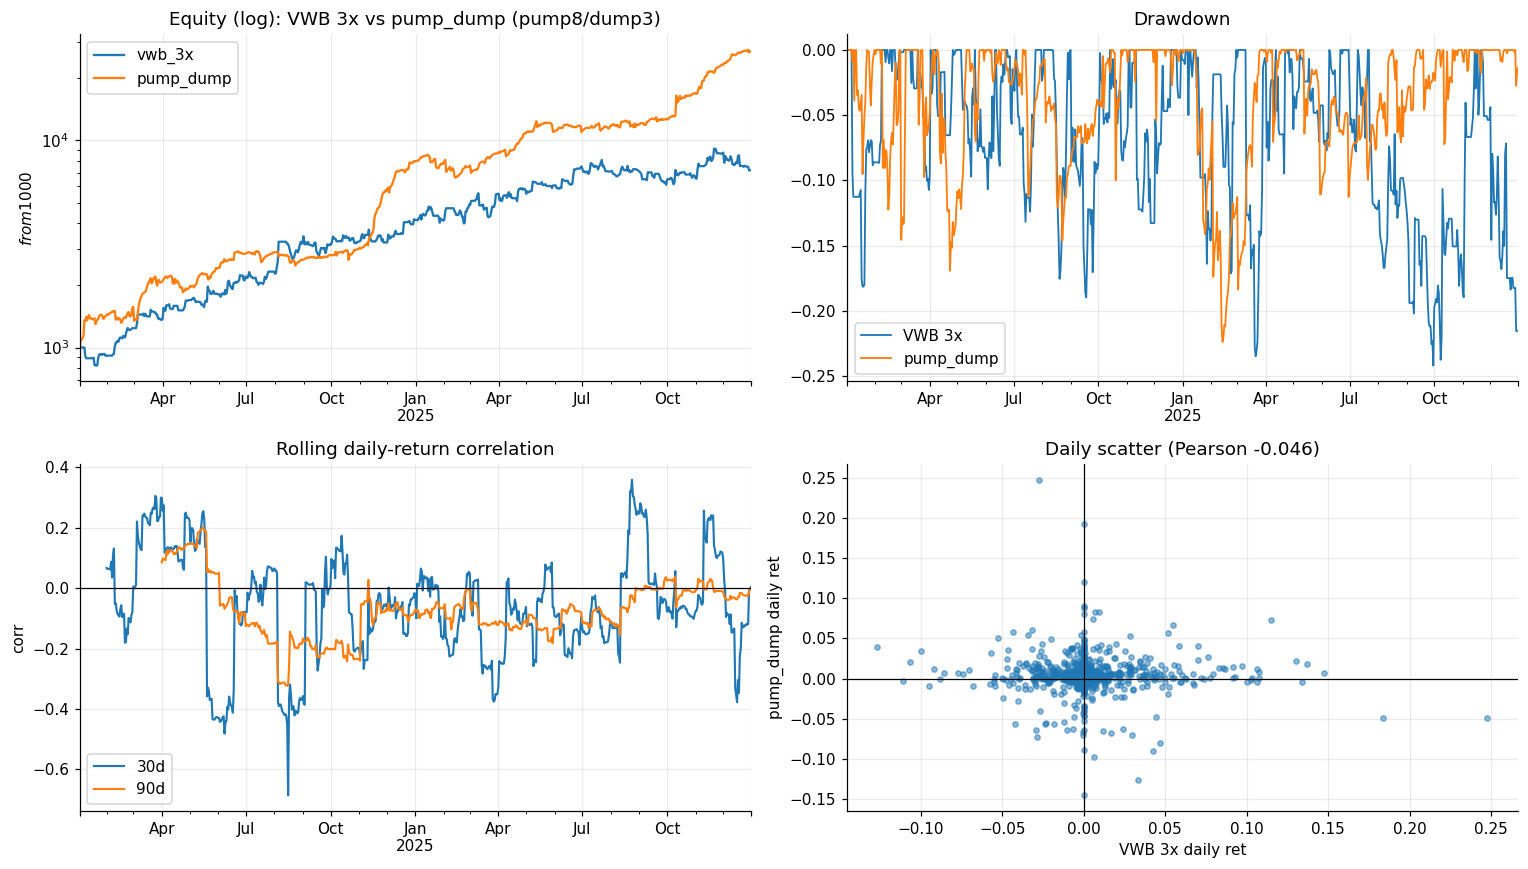

In [6]:
rolling = pd.DataFrame({
    "30d": daily_ret.vwb_3x.rolling(30).corr(daily_ret.pump_dump),
    "90d": daily_ret.vwb_3x.rolling(90).corr(daily_ret.pump_dump),
})
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
(daily/daily.iloc[0]*INITIAL).plot(ax=ax[0,0], lw=1.5, logy=True)
ax[0,0].set_title("Equity (log): VWB 3x vs pump_dump (pump8/dump3)"); ax[0,0].set_ylabel("$ from $1000")
drawdown(daily.vwb_3x).rename("VWB 3x").plot(ax=ax[0,1], lw=1.2)
drawdown(daily.pump_dump).rename("pump_dump").plot(ax=ax[0,1], lw=1.2)
ax[0,1].set_title("Drawdown"); ax[0,1].legend()
rolling.plot(ax=ax[1,0], lw=1.4); ax[1,0].axhline(0, color="k", lw=0.8)
ax[1,0].set_title("Rolling daily-return correlation"); ax[1,0].set_ylabel("corr")
ax[1,1].scatter(daily_ret.vwb_3x, daily_ret.pump_dump, s=12, alpha=0.5)
ax[1,1].axhline(0, color="k", lw=0.8); ax[1,1].axvline(0, color="k", lw=0.8)
ax[1,1].set_title(f"Daily scatter (Pearson {pear:+.3f})")
ax[1,1].set_xlabel("VWB 3x daily ret"); ax[1,1].set_ylabel("pump_dump daily ret")
show("port_11_corr")

## 5. Portfolio weight sweep

Daily-rebalanced synthetic mix `r = w·VWB_3x + (1-w)·pump_dump`. Sweep `w` and read
off the Sharpe-optimal, Calmar-optimal, and minimum-drawdown blends.

In [7]:
weights = np.round(np.arange(0, 1.0001, 0.05), 2)
rows = {}; eqs = {}
for w in weights:
    r = w*daily_ret.vwb_3x + (1-w)*daily_ret.pump_dump
    s = perf(r); s["calmar"] = s["cagr"]/abs(s["max_dd"]) if s["max_dd"]<0 else np.nan
    rows[w] = s; eqs[w] = INITIAL*(1+r).cumprod()
port = pd.DataFrame(rows).T; port.index.name = "vwb_weight"
best_sharpe = port.sharpe.idxmax(); best_calmar = port.calmar.idxmax(); min_dd = port.max_dd.idxmax()
display(port[["cagr","ann_vol","sharpe","max_dd","calmar","worst_day"]].style.format(
    {"cagr":"{:.1%}","ann_vol":"{:.1%}","sharpe":"{:.2f}","max_dd":"{:.1%}","calmar":"{:.1f}","worst_day":"{:.1%}"}))
print(f"best Sharpe : {best_sharpe:.0%} VWB / {1-best_sharpe:.0%} PD  (Sharpe {port.sharpe.max():.2f})")
print(f"best Calmar : {best_calmar:.0%} VWB / {1-best_calmar:.0%} PD  (Calmar {port.calmar.max():.1f})")
print(f"min drawdown: {min_dd:.0%} VWB / {1-min_dd:.0%} PD  (maxDD {port.max_dd.max():.1%})")

,cagr,ann_vol,sharpe,max_dd,calmar,worst_day
vwb_weight,,,,,,
0.000000,420.8%,48.6%,3.64,-22.4%,18.8,-14.6%
0.050000,411.3%,46.1%,3.77,-21.3%,19.3,-13.8%
0.100000,401.2%,43.9%,3.90,-20.3%,19.8,-13.1%
0.150000,390.5%,41.9%,4.01,-19.2%,20.3,-12.4%
0.200000,379.3%,40.2%,4.10,-18.4%,20.6,-11.6%
0.250000,367.6%,38.9%,4.16,-17.7%,20.8,-10.9%
0.300000,355.5%,38.0%,4.19,-17.0%,20.9,-10.2%
0.350000,343.0%,37.4%,4.17,-16.4%,20.9,-9.5%
0.400000,330.2%,37.3%,4.10,-15.7%,21.0,-8.7%


best Sharpe : 30% VWB / 70% PD  (Sharpe 4.19)
best Calmar : 45% VWB / 55% PD  (Calmar 21.0)
min drawdown: 50% VWB / 50% PD  (maxDD -14.5%)


[saved] notebooks\volume_weighted_breakout\_out\port_11_mix.png
[saved] notebooks\volume_weighted_breakout\_out\port_11_frontier.png


WindowsPath('C:/projects/researchlab/notebooks/volume_weighted_breakout/_out/port_11_frontier.png')

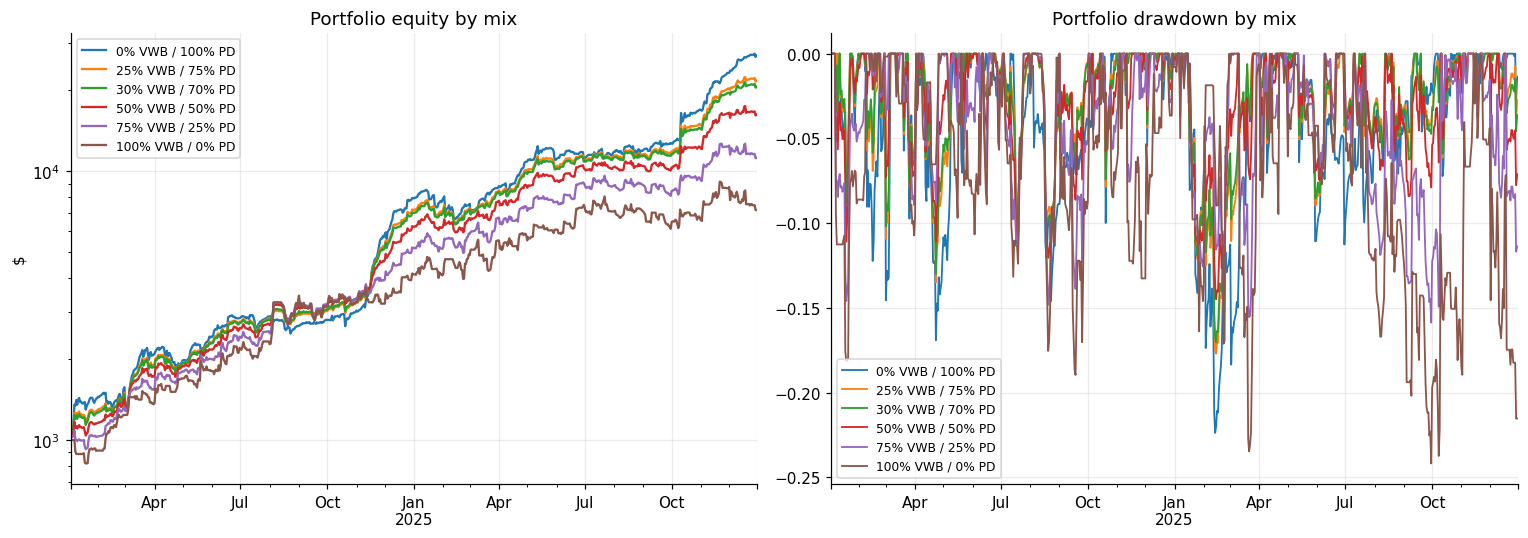

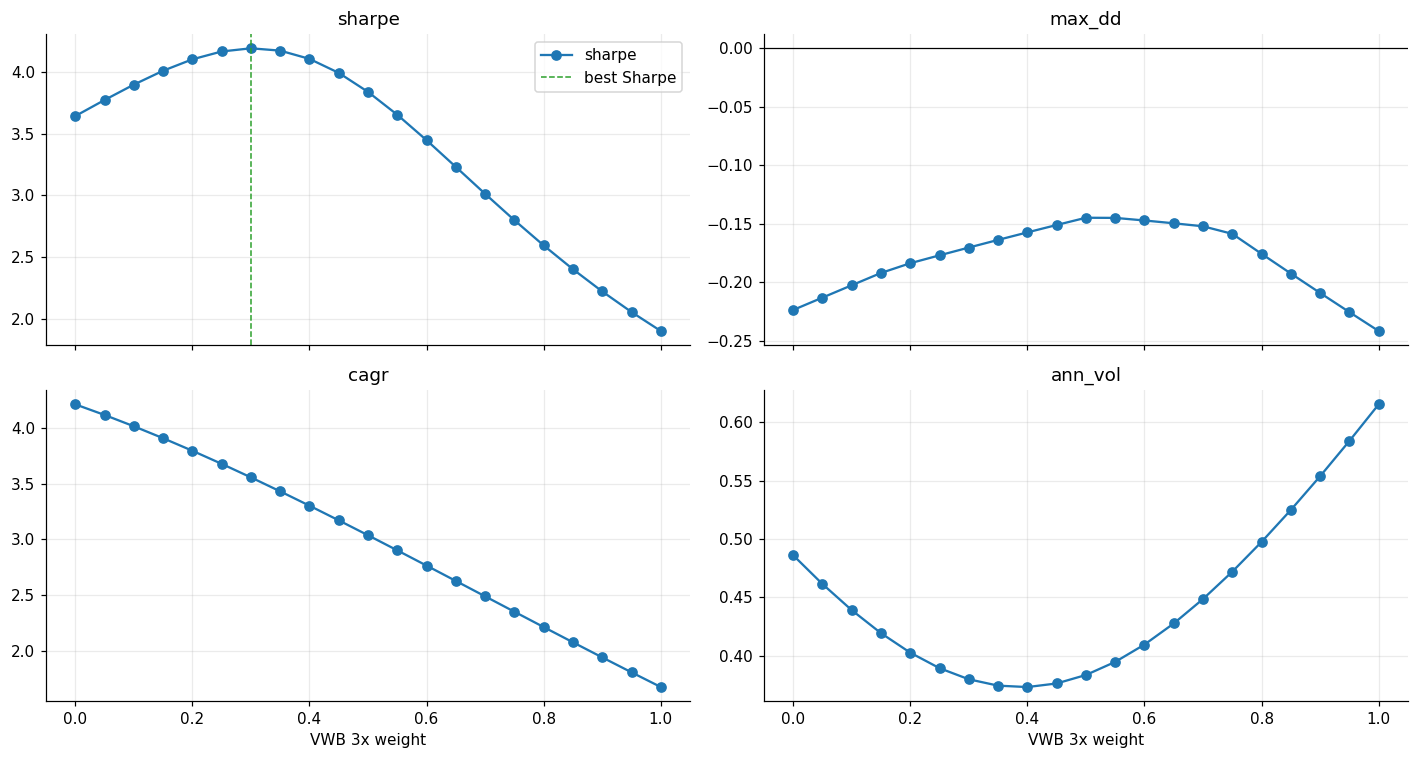

In [8]:
sel = sorted(set([0.0, 0.25, 0.5, 0.75, 1.0, float(best_sharpe), float(min_dd)]))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for w in sel:
    lab = f"{w:.0%} VWB / {1-w:.0%} PD"
    eqs[w].plot(ax=ax[0], lw=1.5, label=lab); drawdown(eqs[w]).plot(ax=ax[1], lw=1.2, label=lab)
ax[0].set_yscale("log"); ax[0].set_title("Portfolio equity by mix"); ax[0].set_ylabel("$"); ax[0].legend(fontsize=8)
ax[1].set_title("Portfolio drawdown by mix"); ax[1].legend(fontsize=8)
show("port_11_mix")

fig, ax = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for a, m in zip(ax.ravel(), ["sharpe","max_dd","cagr","ann_vol"]):
    port[m].plot(ax=a, marker="o"); a.set_title(m); a.set_xlabel("VWB 3x weight")
    if m in ("max_dd",): a.axhline(0, color="k", lw=0.8)
ax[0,0].axvline(best_sharpe, color="C2", ls="--", lw=1, label="best Sharpe"); ax[0,0].legend()
show("port_11_frontier")

## Verdict

**The two lines are essentially uncorrelated** — Pearson ≈ 0, Spearman ≈ 0 — which is
exactly what you'd hope: VWB is a 4h volume-breakout on four majors, pump_dump is a 1m
mean-reversion book on ~170 microcaps. They fire on different assets, horizons, and
regimes, so blending them buys real diversification (not a hedge with negative corr,
just independence).

**Portfolio shape.** pump_dump alone is the higher-Sharpe, higher-return leg (it is an
in-sample small-capital ceiling); VWB 3x is lower-Sharpe with a fat 24% drawdown. Mixing
in a **minority VWB weight lifts Sharpe above either leg** and, around a ~50/50 split,
**cuts portfolio drawdown well below both** — the classic free-lunch signature of
combining independent positive-expectancy streams. Read the exact Sharpe-optimal and
min-DD weights off the sweep above.

**Honest caveats (do not read the absolute numbers as a forecast):**
- Both legs are **in-sample** over one 2024→2026 window with no true alt-mania; the
  pump_dump absolute (Sharpe ~3.6 / CAGR ~4x) is the small-capital ceiling documented
  across the pump_dump line, and its worst trade is still **−37%** (gap tail the stop
  can't touch). pump8/dump3 is the aggressive growth tilt — more money, worse DD than
  the flat-5% bot.
- **VWB 3x leverage is an arbitrary risk dial**, not a property of the strategy; at 1x
  the VWB leg contributes less variance and the optimal weight shifts.
- Correlation is measured on a lump-sum fixed-fraction curve; live capacity, DCA
  cashflows, and slippage realism (nb02/07/12 of pump_dump) all bound the achievable
  size. The **robust takeaway is the near-zero correlation and the diversification
  it enables**, not the headline Sharpe.